# EDA, Feature Selection, and Feature Engineering — METABRIC Breast Cancer

This notebook follows the Checkpoint 2 guide exactly, in order:

1. **EDA** — distributions, missingness, relationships, outliers
2. **Feature Selection** — domain filter → leakage check → low-information → redundancy
3. **Feature Engineering** — domain-driven new features
4. **Summary** — what we keep, drop, and engineer, with justification for each

All decisions are logged in a table at the end (`feature_audit`), which gets saved to `results/feature_selection.csv`.

## 0. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

os.makedirs('results/eda', exist_ok=True)

# missingno is optional — install with: pip install missingno
try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False
    print('missingno not installed — skipping matrix/heatmap plots')

## 1. Load and rename columns

We rename the raw column names to clean snake-case identifiers so the rest of the notebook is readable.
The raw file has 2 509 patients and 39 columns (per the README).

In [2]:
df_raw = pd.read_csv('brca_metabric_clinical_data.tsv', sep='\t')
print(f'Raw shape: {df_raw.shape}')

RENAME = {
    'Overall Survival (Months)':        'OS_MONTHS',
    'Overall Survival Status':          'OS_STATUS',
    'Relapse Free Status (Months)':     'RFS_MONTHS',
    'Relapse Free Status':              'RFS_STATUS',
    "Patient's Vital Status":          'VITAL_STATUS',
    'Pam50 + Claudin-low subtype':      'CLAUDIN_SUBTYPE',
    'Integrative Cluster':              'INTCLUST',
    'ER Status':                        'ER_STATUS',
    'ER status measured by IHC':        'ER_IHC',
    'PR Status':                        'PR_STATUS',
    'HER2 Status':                      'HER2_STATUS',
    'HER2 status measured by SNP6':     'HER2_SNP6',
    'Age at Diagnosis':                 'AGE_AT_DIAGNOSIS',
    'Neoplasm Histologic Grade':        'GRADE',
    'Tumor Stage':                      'TUMOR_STAGE',
    '3-Gene classifier subtype':        'THREEGENE',
    'Mutation Count':                   'MUTATION_COUNT',
    'TMB (nonsynonymous)':              'TMB_NONSYNONYMOUS',
    'Tumor Size':                       'TUMOR_SIZE',
    'Chemotherapy':                     'CHEMOTHERAPY',
    'Radio Therapy':                    'RADIO_THERAPY',
    'Hormone Therapy':                  'HORMONE_THERAPY',
    'Type of Breast Surgery':           'BREAST_SURGERY',
    'Lymph nodes examined positive':    'LYMPH_NODES_POS',
    'Nottingham prognostic index':      'NPI',
    'Sex':                              'SEX',
    'Inferred Menopausal State':        'MENOPAUSAL_STATE',
    'Tumor Other Histologic Subtype':   'HISTOLOGIC_SUBTYPE',
    'Cellularity':                      'CELLULARITY',
    'Primary Tumor Laterality':         'LATERALITY',
    'Number of Samples Per Patient':    'N_SAMPLES',
    'Sample Type':                      'SAMPLE_TYPE',
    'Oncotree Code':                    'ONCOTREE_CODE',
    'Cancer Type':                      'CANCER_TYPE',
    'Cancer Type Detailed':             'CANCER_TYPE_DETAIL',
    'Cohort':                           'COHORT',
}

df = df_raw.rename(columns=RENAME)
print(f'Renamed shape: {df.shape}')
df.head(3)

Raw shape: (2509, 39)
Renamed shape: (2509, 39)


,Study ID,Patient ID,Sample ID,AGE_AT_DIAGNOSIS,BREAST_SURGERY,CANCER_TYPE,CANCER_TYPE_DETAIL,CELLULARITY,CHEMOTHERAPY,CLAUDIN_SUBTYPE,...,RFS_MONTHS,RFS_STATUS,N_SAMPLES,SAMPLE_TYPE,SEX,THREEGENE,TMB_NONSYNONYMOUS,TUMOR_SIZE,TUMOR_STAGE,VITAL_STATUS
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,...,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,...,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,...,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease


## 2. EDA — Univariate distributions

**Why:** Before selecting or engineering features, we need to understand the shape of each variable.
Skewed distributions may need log-transformation; bimodal ones may hide subgroups; near-constant columns are candidates for dropping.

We split columns into numeric and categorical and plot each group separately.

In [33]:
# Separate numeric and categorical columns
# Exclude identifier-like columns and outcome columns for now
EXCLUDE = ['Study ID', 'Patient ID', 'Sample ID']

num_cols = [c for c in df.select_dtypes(include='number').columns if c not in EXCLUDE]
cat_cols = [c for c in df.select_dtypes(include='object').columns if c not in EXCLUDE]

print(f'Numeric columns ({len(num_cols)}): {num_cols}')
print(f'\nCategorical columns ({len(cat_cols)}): {cat_cols}')

Numeric columns (12): ['AGE_AT_DIAGNOSIS', 'COHORT', 'GRADE', 'LYMPH_NODES_POS', 'MUTATION_COUNT', 'NPI', 'OS_MONTHS', 'RFS_MONTHS', 'N_SAMPLES', 'TMB_NONSYNONYMOUS', 'TUMOR_SIZE', 'TUMOR_STAGE']

Categorical columns (24): ['BREAST_SURGERY', 'CANCER_TYPE', 'CANCER_TYPE_DETAIL', 'CELLULARITY', 'CHEMOTHERAPY', 'CLAUDIN_SUBTYPE', 'ER_IHC', 'ER_STATUS', 'HER2_SNP6', 'HER2_STATUS', 'HISTOLOGIC_SUBTYPE', 'HORMONE_THERAPY', 'MENOPAUSAL_STATE', 'INTCLUST', 'LATERALITY', 'ONCOTREE_CODE', 'OS_STATUS', 'PR_STATUS', 'RADIO_THERAPY', 'RFS_STATUS', 'SAMPLE_TYPE', 'SEX', 'THREEGENE', 'VITAL_STATUS']


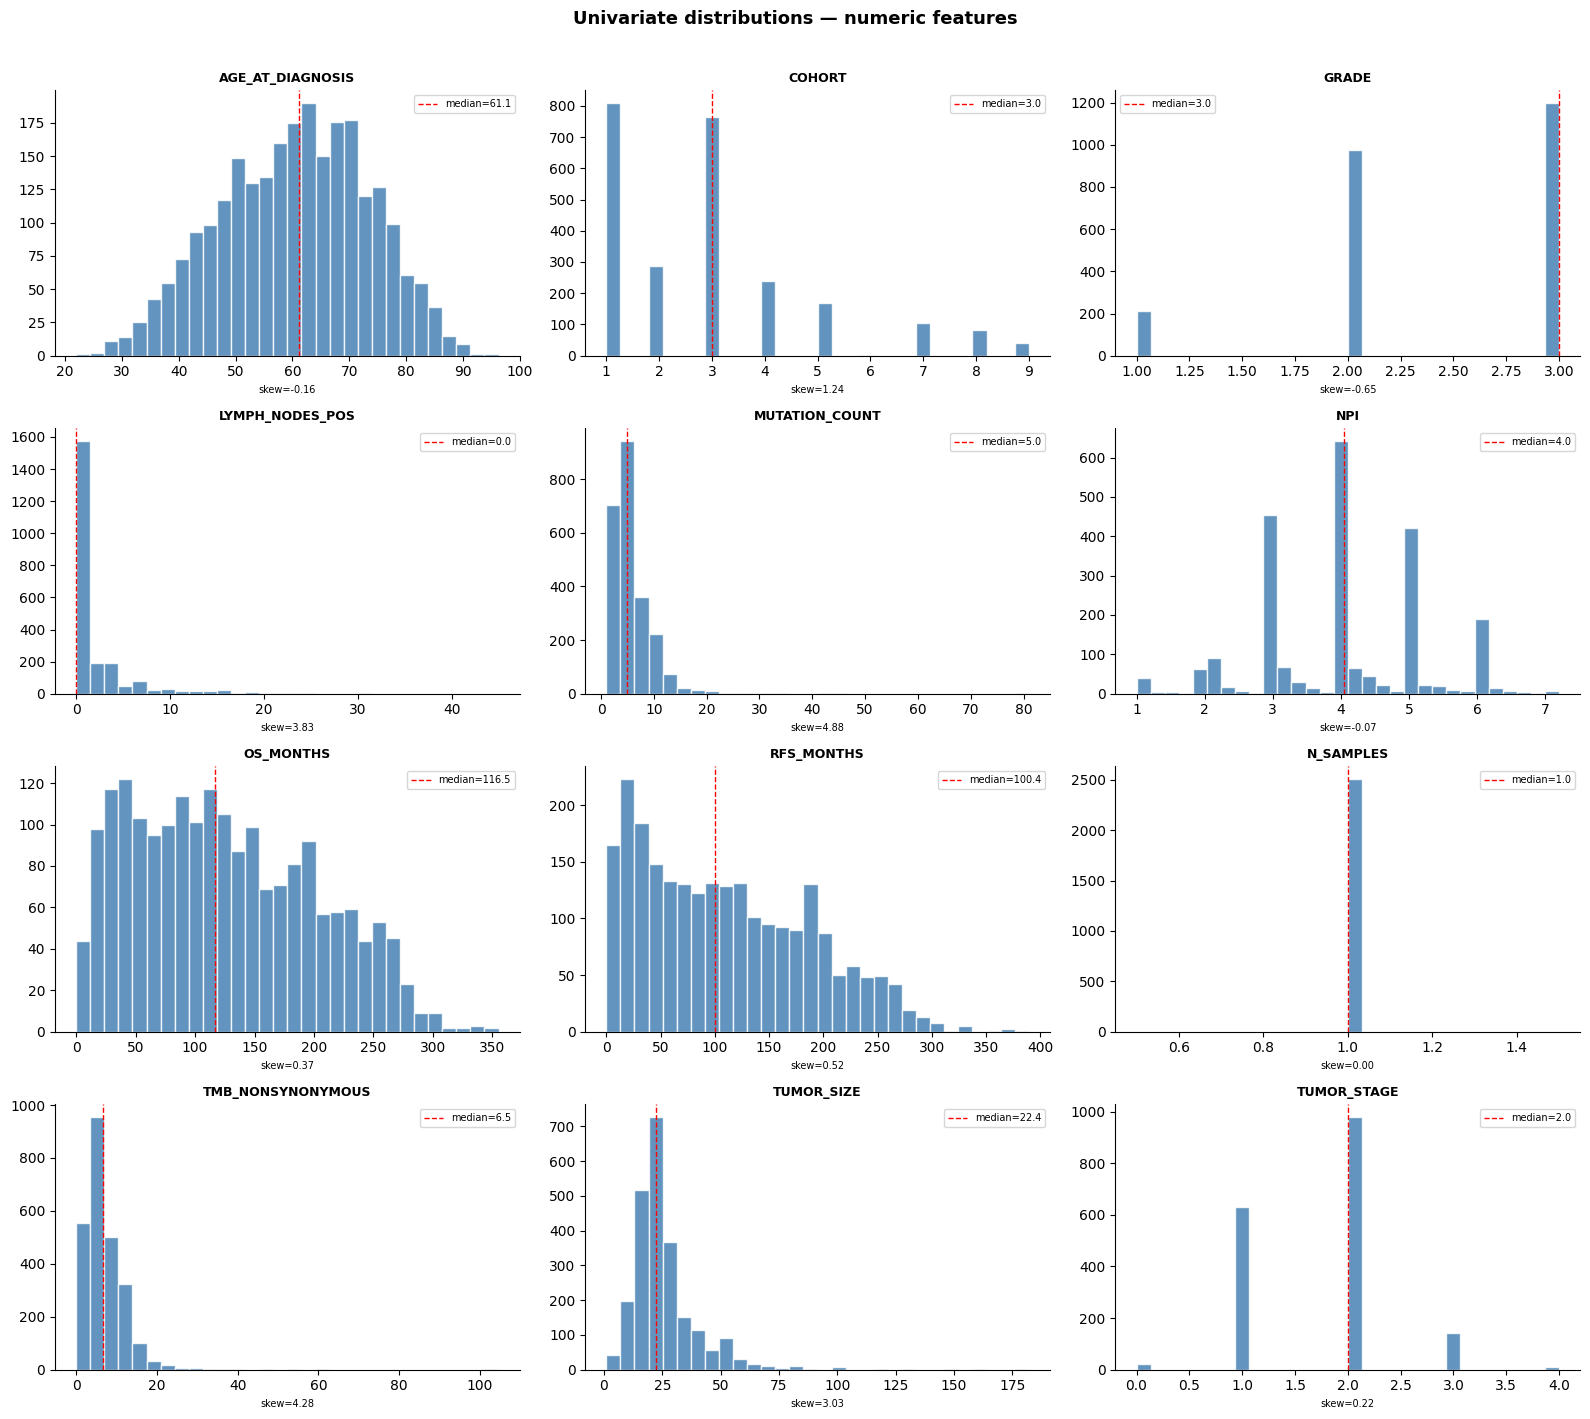

Highly skewed features (|skew| > 1) will likely need log-transform before modeling.


In [4]:
# ── Numeric distributions ──
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.median(), color='red', linestyle='--', linewidth=1,
                    label=f'median={data.median():.1f}')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    skew = data.skew()
    axes[i].set_xlabel(f'skew={skew:.2f}', fontsize=7)

# hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate distributions — numeric features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/eda/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Highly skewed features (|skew| > 1) will likely need log-transform before modeling.')

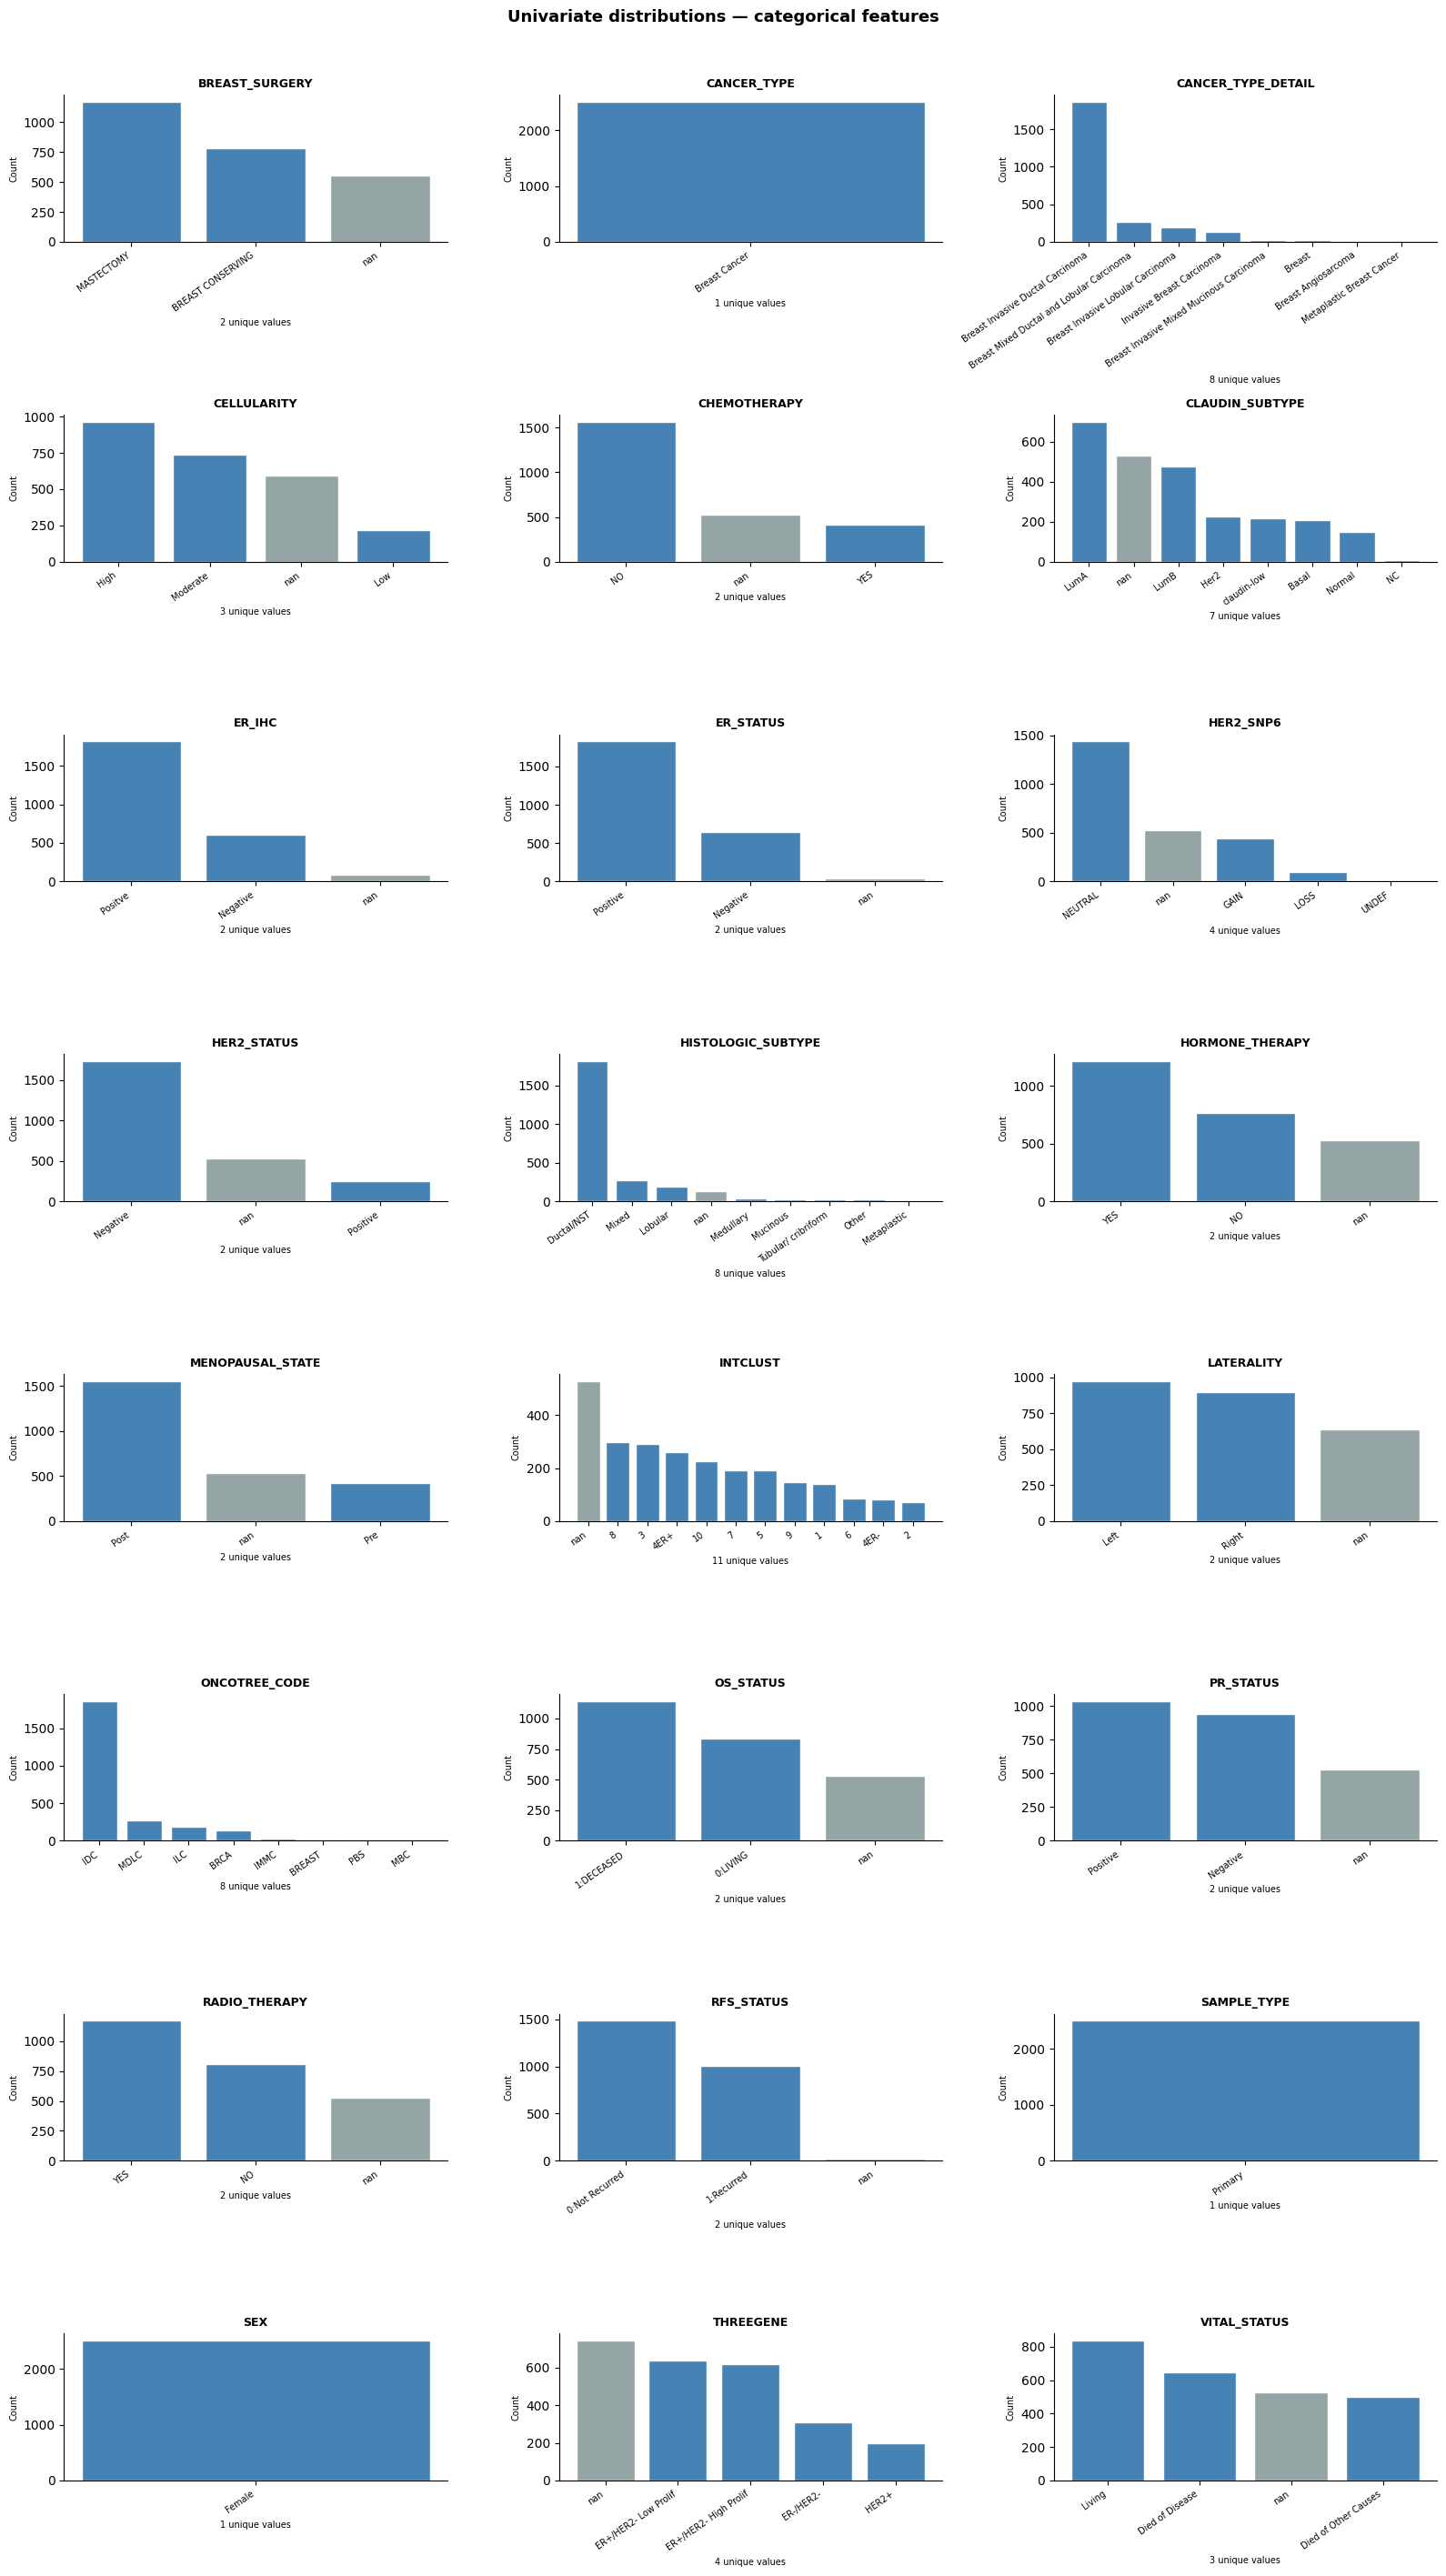

In [34]:
# ── Categorical distributions ──
n = len(cat_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts(dropna=False)
    colors = ['#95a5a6' if pd.isna(v) else 'steelblue' for v in counts.index]
    axes[i].bar(range(len(counts)), counts.values, color=colors, edgecolor='white')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels([str(v) for v in counts.index], rotation=35, ha='right', fontsize=7)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Count', fontsize=7)
    n_unique = df[col].nunique()
    axes[i].set_xlabel(f'{n_unique} unique values', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate distributions — categorical features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/eda/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. EDA — Missing data

**Why:** Missing data affects every downstream step — imputation strategy, model choice, and whether a column is usable at all.
We need to:
1. **Quantify** how much is missing per column
2. **Visualize the pattern** — is missingness random, or do the same patients tend to be missing across multiple columns?
   If it's structured (e.g., patients missing `TUMOR_SIZE` also miss `GRADE`), that tells us something biological or about data collection.

Tools: `pandas.isna`, `missingno.matrix`, `missingno.heatmap`

In [35]:
# Count and percentage missing per column
miss = pd.DataFrame({
    'missing_n':   df.isnull().sum(),
    'missing_pct': df.isnull().mean() * 100
}).sort_values('missing_pct', ascending=False)

miss = miss[miss['missing_n'] > 0]
print(f'{len(miss)} columns have missing values:\n')
print(miss.to_string())

29 columns have missing values:

                    missing_n  missing_pct
THREEGENE                 745    29.693105
TUMOR_STAGE               721    28.736548
LATERALITY                639    25.468314
CELLULARITY               592    23.595058
BREAST_SURGERY            554    22.080510
MENOPAUSAL_STATE          529    21.084097
HORMONE_THERAPY           529    21.084097
INTCLUST                  529    21.084097
RADIO_THERAPY             529    21.084097
HER2_STATUS               529    21.084097
VITAL_STATUS              529    21.084097
PR_STATUS                 529    21.084097
HER2_SNP6                 529    21.084097
CLAUDIN_SUBTYPE           529    21.084097
CHEMOTHERAPY              529    21.084097
OS_STATUS                 528    21.044241
OS_MONTHS                 528    21.044241
LYMPH_NODES_POS           266    10.601833
NPI                       222     8.848147
MUTATION_COUNT            151     6.018334
TUMOR_SIZE                149     5.938621
HISTOLOGIC_SUBTYPE   

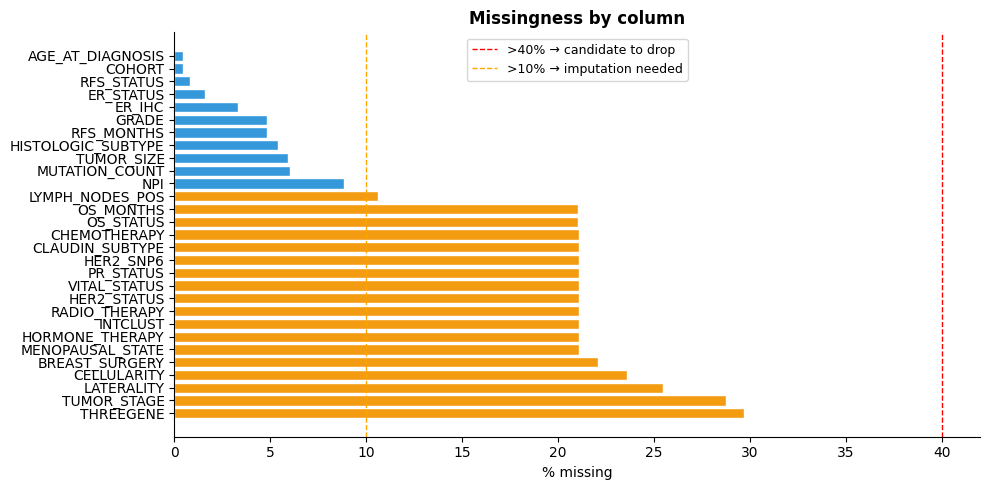

In [7]:
# Bar chart of missingness
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if p > 40 else '#f39c12' if p > 10 else '#3498db'
          for p in miss['missing_pct']]
ax.barh(miss.index, miss['missing_pct'], color=colors, edgecolor='white')
ax.axvline(40, color='red', linestyle='--', linewidth=1, label='>40% → candidate to drop')
ax.axvline(10, color='orange', linestyle='--', linewidth=1, label='>10% → imputation needed')
ax.set_xlabel('% missing')
ax.set_title('Missingness by column', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('results/eda/missingness_bar.png', dpi=150, bbox_inches='tight')
plt.show()

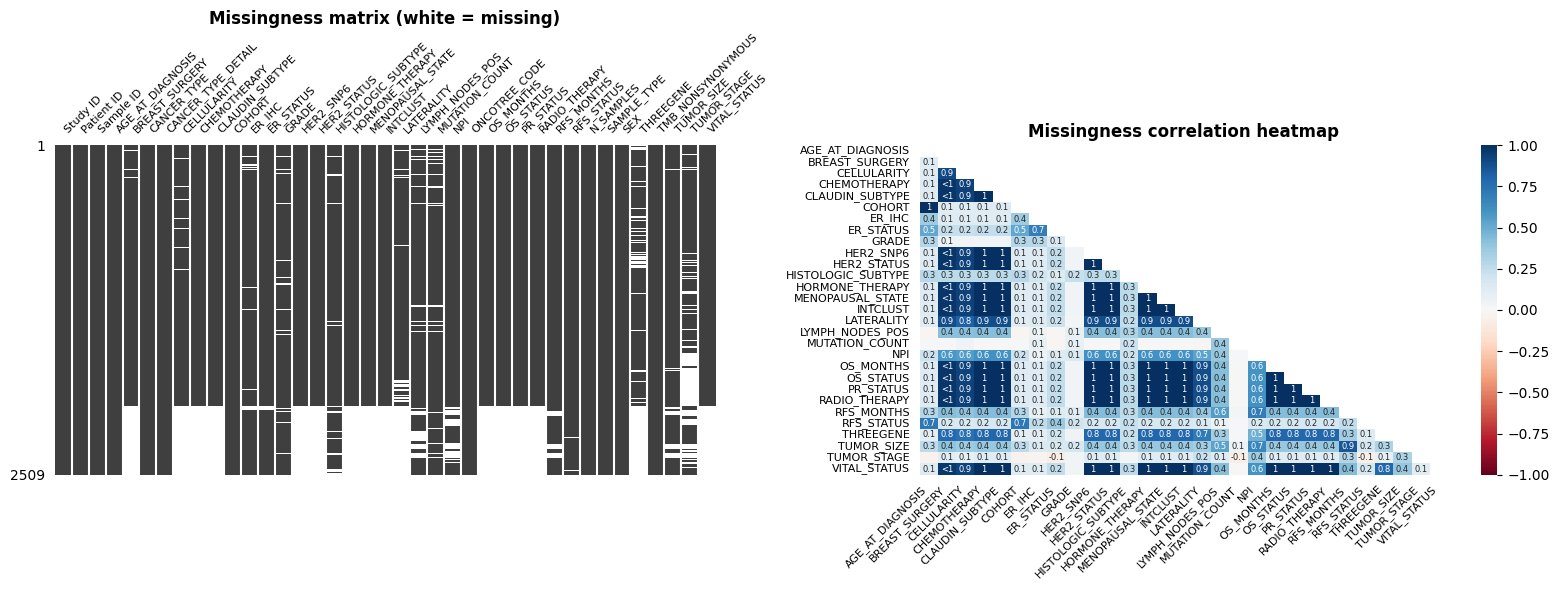

In [36]:
# missingno matrix — shows co-occurrence patterns of missingness across rows
# Gray = present, white = missing. Vertical white stripes = the same patients missing many columns.
if HAS_MSNO:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    msno.matrix(df, ax=axes[0], sparkline=False, fontsize=8)
    axes[0].set_title('Missingness matrix (white = missing)', fontweight='bold')
    msno.heatmap(df, ax=axes[1], fontsize=8)
    axes[1].set_title('Missingness correlation heatmap', fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/eda/missingness_pattern.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # manual co-occurrence heatmap as fallback
    miss_cols = miss.index.tolist()
    co = df[miss_cols].isnull().astype(int).corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(co, cmap='Reds', ax=ax, linewidths=0.3, annot=len(miss_cols) <= 15, fmt='.1f')
    ax.set_title('Missingness correlation (1 = always missing together)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/eda/missingness_pattern.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. EDA — Relationships between variables

**Why:** We need to understand which features are correlated with the outcome (`OS_MONTHS`) and with each other.
Highly correlated feature pairs are redundancy candidates. Features uncorrelated with the outcome are low-signal candidates.

We look at:
- Correlation heatmap across all numeric features
- Group summaries (median values by `CLAUDIN_SUBTYPE`)
- Key feature vs. OS_MONTHS scatterplots

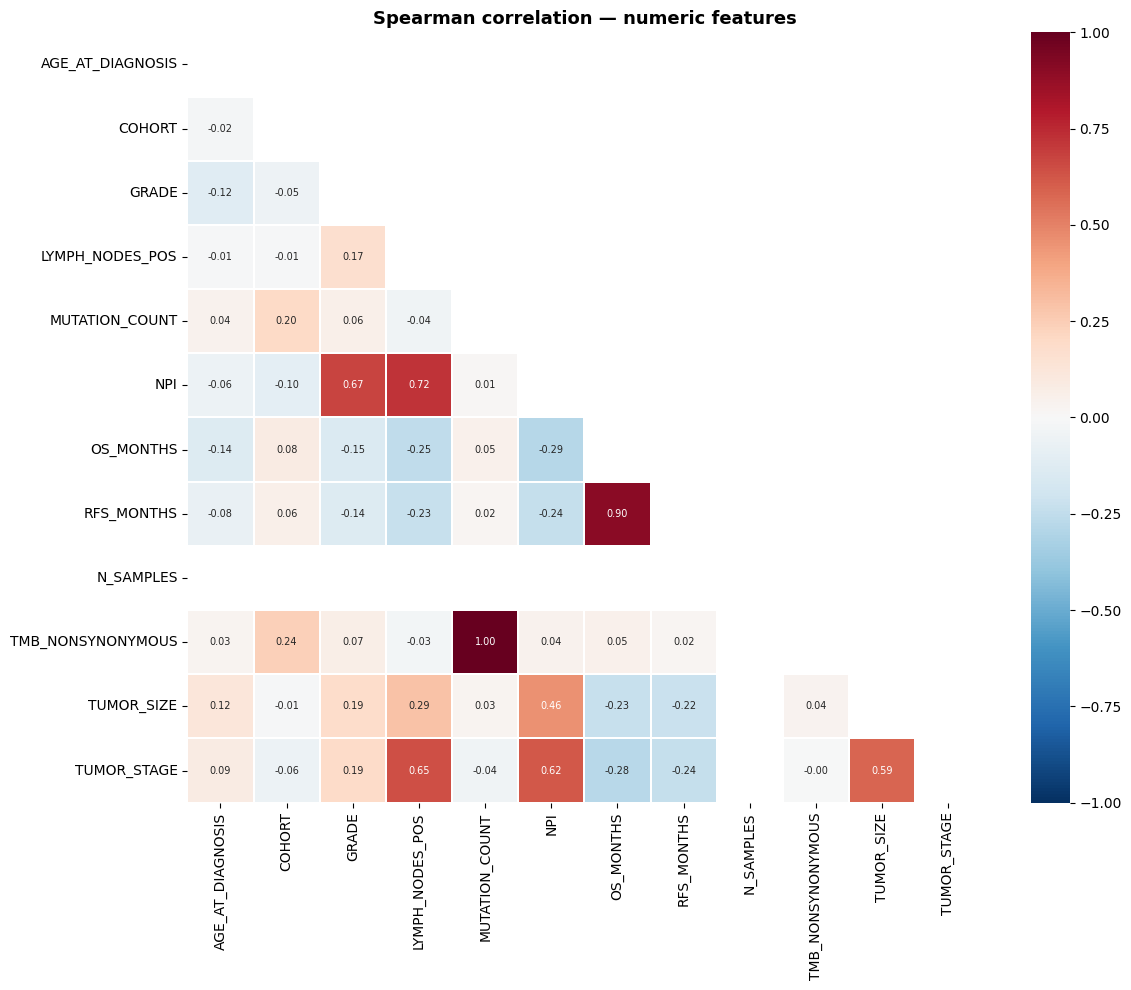

Pairs with |r| > 0.7 are redundancy candidates — we will revisit these in Feature Selection.


In [37]:
# Correlation heatmap — numeric features only
# We use Spearman because several features are ordinal (GRADE, TUMOR_STAGE)
# or skewed (MUTATION_COUNT, TUMOR_SIZE).

corr_cols = [c for c in num_cols if df[c].notna().sum() > 500]  # skip near-empty columns
corr = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, ax=ax)
ax.set_title('Spearman correlation — numeric features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/eda/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Pairs with |r| > 0.7 are redundancy candidates — we will revisit these in Feature Selection.')

In [38]:
# Group summary by CLAUDIN_SUBTYPE
# This helps us see whether features differ meaningfully across subtypes —
# features that show no variation across groups may not be informative for subtype-aware modeling.

summary_cols = ['OS_MONTHS', 'AGE_AT_DIAGNOSIS', 'TUMOR_SIZE', 'GRADE',
                'TUMOR_STAGE', 'MUTATION_COUNT', 'TMB_NONSYNONYMOUS', 'NPI', 'LYMPH_NODES_POS']
summary_cols = [c for c in summary_cols if c in df.columns]

group_summary = (
    df.dropna(subset=['CLAUDIN_SUBTYPE'])
      .groupby('CLAUDIN_SUBTYPE')[summary_cols]
      .median()
      .round(2)
)
print('Median values by molecular subtype:')
print(group_summary.T.to_string())

Median values by molecular subtype:
CLAUDIN_SUBTYPE    Basal   Her2    LumA    LumB      NC  Normal  claudin-low
OS_MONTHS          85.50  97.07  130.08  104.10  144.13  121.07       116.18
AGE_AT_DIAGNOSIS   54.22  59.06   63.37   66.52   72.09   57.14        58.68
TUMOR_SIZE         25.00  25.00   20.00   25.00   17.50   23.00        20.00
GRADE               3.00   3.00    2.00    3.00    2.00    2.00         3.00
TUMOR_STAGE         2.00   2.00    2.00    2.00    2.00    2.00         2.00
MUTATION_COUNT      5.00   6.00    5.00    5.00    6.00    4.00         4.00
TMB_NONSYNONYMOUS   6.54   7.85    6.54    6.54    7.85    5.23         3.92
NPI                 5.02   4.08    3.08    4.05    4.05    4.02         4.04
LYMPH_NODES_POS     1.00   1.00    0.00    1.00    1.00    0.00         0.00


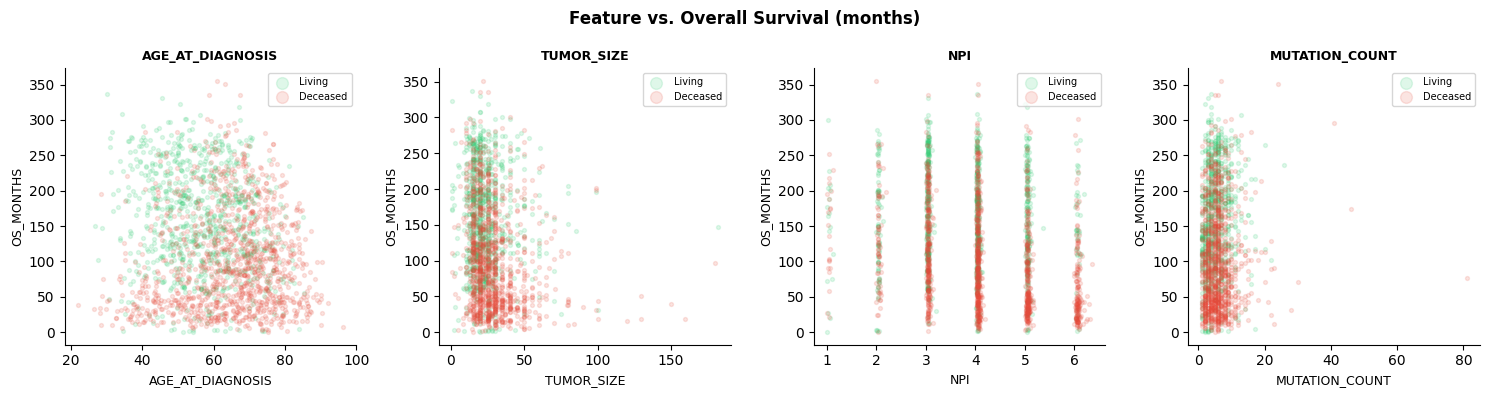

In [39]:
# Scatterplots of key numeric features vs. OS_MONTHS
# Color by deceased status to see separation.

df_plot = df.dropna(subset=['OS_MONTHS', 'OS_STATUS']).copy()
df_plot['deceased'] = df_plot['OS_STATUS'].str.upper().str.contains('DECEASED|DEAD|1').astype(int)

plot_features = ['AGE_AT_DIAGNOSIS', 'TUMOR_SIZE', 'NPI', 'MUTATION_COUNT']
plot_features = [c for c in plot_features if c in df_plot.columns]

fig, axes = plt.subplots(1, len(plot_features), figsize=(15, 4))
for ax, feat in zip(axes, plot_features):
    for status, color, label in [(0, '#2ecc71', 'Living'), (1, '#e74c3c', 'Deceased')]:
        mask = df_plot['deceased'] == status
        ax.scatter(df_plot.loc[mask, feat], df_plot.loc[mask, 'OS_MONTHS'],
                   alpha=0.15, s=8, color=color, label=label)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('OS_MONTHS', fontsize=9)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, markerscale=3)

plt.suptitle('Feature vs. Overall Survival (months)', fontweight='bold')
plt.tight_layout()
plt.savefig('results/eda/feature_vs_os.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. EDA — Outlier detection

**Why:** Outliers can distort model coefficients (especially in linear models) and inflate feature importance in tree models.
We want to flag them — not necessarily remove them, but understand whether they are:
- **Data entry errors** → should be removed or corrected
- **Genuine extreme cases** → should be kept, but noted

We use two approaches:
1. **Z-score** (|z| > 3) — fast univariate flag
2. **Isolation Forest** — catches multivariate outliers that look normal on each axis alone

In [40]:
# Z-score outlier flagging
# Any patient with |z| > 3 on at least one numeric column is flagged.

z_cols = [c for c in num_cols if df[c].notna().sum() > 500 and c not in ['OS_MONTHS', 'RFS_MONTHS']]
df_z = df[z_cols].copy()

z_scores = df_z.apply(lambda col: np.abs(stats.zscore(col.dropna())))

outlier_counts = {}
for col in z_cols:
    valid_idx = df[col].notna()
    z = np.abs(stats.zscore(df.loc[valid_idx, col]))
    outlier_counts[col] = (z > 3).sum()

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
print('Patients with |z| > 3 per feature:')
print(outlier_series[outlier_series > 0].to_string())

Patients with |z| > 3 per feature:
LYMPH_NODES_POS      58
COHORT               40
TUMOR_SIZE           37
TMB_NONSYNONYMOUS    26
MUTATION_COUNT       26
TUMOR_STAGE          11


C:\Users\mma3012\AppData\Local\Temp\ipykernel_65424\3380222820.py:7: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = df_z.apply(lambda col: np.abs(stats.zscore(col.dropna())))
C:\Users\mma3012\AppData\Local\Temp\ipykernel_65424\3380222820.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z = np.abs(stats.zscore(df.loc[valid_idx, col]))


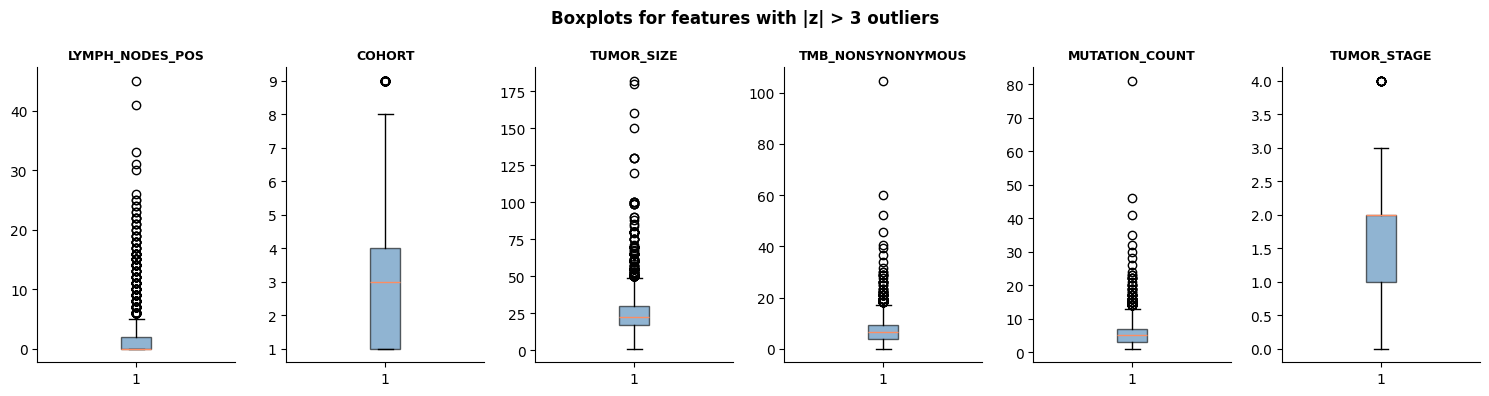

In [41]:
# Boxplots to visualize outliers for the most affected features
top_outlier_cols = outlier_series[outlier_series > 0].head(6).index.tolist()

if top_outlier_cols:
    fig, axes = plt.subplots(1, len(top_outlier_cols), figsize=(15, 4))
    if len(top_outlier_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, top_outlier_cols):
        ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6))
        ax.set_title(col, fontsize=9, fontweight='bold')
        ax.set_xlabel('')
    plt.suptitle('Boxplots for features with |z| > 3 outliers', fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/eda/outlier_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()

In [42]:
# Isolation Forest — multivariate outlier detection
# Fit on patients with complete numeric data.
# contamination=0.05 means we expect ~5% of patients to be outliers.

iso_cols = [c for c in z_cols if df[c].notna().mean() > 0.8]  # only well-populated columns
df_iso = df[iso_cols].dropna()

iso = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso.fit_predict(df_iso)  # -1 = outlier, 1 = inlier

n_outliers = (iso_labels == -1).sum()
print(f'Isolation Forest flags {n_outliers} patients ({n_outliers/len(df_iso)*100:.1f}%) as multivariate outliers')
print(f'These patients are unusual across MULTIPLE features simultaneously.')
print('\nWe note them but do not remove them automatically — clinical outliers may be biologically real.')

Isolation Forest flags 99 patients (5.0%) as multivariate outliers
These patients are unusual across MULTIPLE features simultaneously.

We note them but do not remove them automatically — clinical outliers may be biologically real.


## 6. Feature Selection — Step 1: Domain knowledge filter

**Why:** The document says: *"Do not include variables just because they exist."*
Including irrelevant features causes the **curse of dimensionality** — too many predictors leads to overfitting and noise.

We go through every column and decide: does this have a **plausible, defensible connection to breast cancer survival**?
If not, it gets dropped here. We record the reason for each drop.

In [43]:
# Every column and our domain-knowledge decision
# Decision: KEEP, DROP, OUTCOME (part of target, handle separately), LEAKAGE (handled next step)

domain_decisions = {
    # Identifiers — no predictive value
    'Study ID':            ('DROP',    'Identifier — no predictive content'),
    'Patient ID':          ('DROP',    'Identifier — no predictive content'),
    'Sample ID':           ('DROP',    'Identifier — no predictive content'),

    # Cancer type — all patients have breast cancer, no variation
    'CANCER_TYPE':         ('DROP',    'Constant: all rows = "Breast Cancer"'),
    'CANCER_TYPE_DETAIL':  ('DROP',    'Near-constant: mostly Ductal Carcinoma'),
    'ONCOTREE_CODE':       ('DROP',    'Near-constant: mostly IDC, redundant with cancer type'),

    # Sample metadata
    'N_SAMPLES':           ('DROP',    'Administrative — number of samples per patient, not clinical'),
    'SAMPLE_TYPE':         ('DROP',    'Constant: all Primary'),
    'COHORT':              ('DROP',    'Cohort index (1–2) — internal batch variable, not a clinical feature'),
    'SEX':                 ('DROP',    'Constant: all Female in METABRIC'),
    'LATERALITY':          ('DROP',    'Tumor side (left/right) — no established survival signal'),

    # Outcome columns — these are what we are predicting, not features
    'OS_MONTHS':           ('OUTCOME', 'Survival time — this is the target variable'),
    'OS_STATUS':           ('OUTCOME', 'Event indicator — part of the target'),
    'VITAL_STATUS':        ('LEAKAGE', 'Direct re-encoding of OS_STATUS — pure leakage'),
    'RFS_MONTHS':          ('LEAKAGE', 'Relapse time — only known after follow-up, post-diagnosis'),
    'RFS_STATUS':          ('LEAKAGE', 'Relapse event — post-diagnosis, leakage for prediction at diagnosis'),

    # Subtype columns — CLAUDIN_SUBTYPE is central; others overlap
    'CLAUDIN_SUBTYPE':     ('KEEP',    'Primary molecular subtype — central to both problem statements'),
    'INTCLUST':            ('KEEP',    'Integrative cluster from Curtis 2012 — additional subtype signal'),
    'THREEGENE':           ('CHECK',   'Overlaps with ER/HER2 status — check redundancy with receptor columns'),

    # Receptor status — two versions of ER and HER2
    'ER_STATUS':           ('KEEP',    'Clinical ER status — key predictor'),
    'ER_IHC':              ('CHECK',   'IHC measurement of ER — likely redundant with ER_STATUS, check correlation'),
    'PR_STATUS':           ('KEEP',    'PR status — independent predictor'),
    'HER2_STATUS':         ('KEEP',    'Clinical HER2 status — key predictor'),
    'HER2_SNP6':           ('CHECK',   'SNP6 measurement of HER2 — likely redundant with HER2_STATUS'),

    # Demographics
    'AGE_AT_DIAGNOSIS':    ('KEEP',    'Strong independent predictor of breast cancer outcomes'),
    'MENOPAUSAL_STATE':    ('KEEP',    'Correlated with age but has independent clinical meaning'),

    # Tumor characteristics
    'GRADE':               ('KEEP',    'Tumor grade — standard prognostic factor'),
    'TUMOR_STAGE':         ('KEEP',    'TNM stage — standard prognostic factor'),
    'TUMOR_SIZE':          ('KEEP',    'Tumor size — component of staging, independent signal'),
    'LYMPH_NODES_POS':     ('KEEP',    'Positive lymph nodes — one of the strongest prognostic factors'),
    'NPI':                 ('CHECK',   'Nottingham Prognostic Index = composite of Grade + Size + Nodes — check redundancy'),
    'HISTOLOGIC_SUBTYPE':  ('KEEP',    'Ductal vs. lobular vs. other — has survival signal'),
    'CELLULARITY':         ('KEEP',    'Tumor cellularity — associated with response and prognosis'),

    # Genomics
    'MUTATION_COUNT':      ('KEEP',    'Total mutation burden — signal for immune response and prognosis'),
    'TMB_NONSYNONYMOUS':   ('CHECK',   'TMB is highly correlated with MUTATION_COUNT — check redundancy'),

    # Treatment
    'CHEMOTHERAPY':        ('KEEP',    'Treatment received — important covariate (note: not randomized in METABRIC)'),
    'RADIO_THERAPY':       ('KEEP',    'Treatment received — important covariate'),
    'HORMONE_THERAPY':     ('KEEP',    'Treatment received — especially relevant for ER+ patients'),
    'BREAST_SURGERY':      ('KEEP',    'Mastectomy vs. conserving — associated with stage and outcomes'),
}

# Print summary
decision_summary = pd.Series({k: v[0] for k, v in domain_decisions.items()}).value_counts()
print('Domain knowledge filter decisions:')
print(decision_summary.to_string())
print()

drops = [k for k, v in domain_decisions.items() if v[0] == 'DROP']
print(f'Columns to DROP ({len(drops)}): {drops}')

Domain knowledge filter decisions:
KEEP       18
DROP       11
CHECK       5
LEAKAGE     3
OUTCOME     2

Columns to DROP (11): ['Study ID', 'Patient ID', 'Sample ID', 'CANCER_TYPE', 'CANCER_TYPE_DETAIL', 'ONCOTREE_CODE', 'N_SAMPLES', 'SAMPLE_TYPE', 'COHORT', 'SEX', 'LATERALITY']


In [44]:
# Apply domain-knowledge drops
DROP_DOMAIN = [k for k, v in domain_decisions.items() if v[0] == 'DROP' and k in df.columns]
df_filtered = df.drop(columns=DROP_DOMAIN)
print(f'Shape after domain filter: {df_filtered.shape} (dropped {len(DROP_DOMAIN)} columns)')
print(f'Remaining columns: {df_filtered.columns.tolist()}')

Shape after domain filter: (2509, 28) (dropped 11 columns)
Remaining columns: ['AGE_AT_DIAGNOSIS', 'BREAST_SURGERY', 'CELLULARITY', 'CHEMOTHERAPY', 'CLAUDIN_SUBTYPE', 'ER_IHC', 'ER_STATUS', 'GRADE', 'HER2_SNP6', 'HER2_STATUS', 'HISTOLOGIC_SUBTYPE', 'HORMONE_THERAPY', 'MENOPAUSAL_STATE', 'INTCLUST', 'LYMPH_NODES_POS', 'MUTATION_COUNT', 'NPI', 'OS_MONTHS', 'OS_STATUS', 'PR_STATUS', 'RADIO_THERAPY', 'RFS_MONTHS', 'RFS_STATUS', 'THREEGENE', 'TMB_NONSYNONYMOUS', 'TUMOR_SIZE', 'TUMOR_STAGE', 'VITAL_STATUS']


## 7. Feature Selection — Step 2: Leakage check

**Why:** A **leaky feature** is one that contains information about the outcome that would not be available at prediction time.
Using leaky features leads to models that look great in cross-validation but fail completely in production.

In a **diagnosis-time prediction** (problem statement #2), we can only use features known at the moment of diagnosis.
Post-diagnosis outcomes like relapse status are **not available** at prediction time.

For problem statement #1 (adjusted survival analysis), we keep treatment variables but flag them as confounders, not predictors.

In [45]:
# Features flagged as LEAKAGE in the domain decision table
LEAKAGE_COLS = [k for k, v in domain_decisions.items() if v[0] == 'LEAKAGE' and k in df_filtered.columns]
print(f'Leakage columns to remove: {LEAKAGE_COLS}')
for col in LEAKAGE_COLS:
    print(f'  {col}: {domain_decisions[col][1]}')

df_filtered = df_filtered.drop(columns=LEAKAGE_COLS, errors='ignore')
print(f'\nShape after leakage drop: {df_filtered.shape}')

Leakage columns to remove: ['VITAL_STATUS', 'RFS_MONTHS', 'RFS_STATUS']
  VITAL_STATUS: Direct re-encoding of OS_STATUS — pure leakage
  RFS_MONTHS: Relapse time — only known after follow-up, post-diagnosis
  RFS_STATUS: Relapse event — post-diagnosis, leakage for prediction at diagnosis

Shape after leakage drop: (2509, 25)


## 8. Feature Selection — Step 3: Low-information features

**Why:** Two types of columns waste model capacity without contributing signal:
1. **Near-constant columns** — if a feature barely varies, it cannot explain variation in the outcome
2. **High-missingness columns** — columns missing >40% of data are unreliable; imputing that much introduces more noise than signal

The document warns that "near-constant" is **contextual** — a tiny numerical range can be clinically meaningful (drug dosage) or completely irrelevant (request latency).
We use domain knowledge alongside the numbers.

In [46]:
# Check variance (for numeric) and value_counts entropy (for categorical)
low_info = []

for col in df_filtered.columns:
    if col in ['OS_MONTHS', 'OS_STATUS']:
        continue

    miss_pct = df_filtered[col].isna().mean() * 100

    if df_filtered[col].dtype in ['float64', 'int64']:
        cv = df_filtered[col].std() / (df_filtered[col].mean() + 1e-9)  # coefficient of variation
        flag = miss_pct > 40 or abs(cv) < 0.01
        low_info.append({'column': col, 'miss_pct': round(miss_pct, 1), 'cv': round(cv, 3), 'flag': flag})
    else:
        top_freq = df_filtered[col].value_counts(normalize=True).iloc[0] * 100
        flag = miss_pct > 40 or top_freq > 98
        low_info.append({'column': col, 'miss_pct': round(miss_pct, 1), 'top_value_pct': round(top_freq, 1), 'flag': flag})

low_info_df = pd.DataFrame(low_info)
flagged = low_info_df[low_info_df['flag']]
print(f'Flagged as low-information: {len(flagged)} columns\n')
print(flagged.to_string(index=False))

Flagged as low-information: 0 columns

Empty DataFrame
Columns: [column, miss_pct, cv, flag, top_value_pct]
Index: []


In [47]:
# Final decision on flagged low-info columns
# We review each one with domain knowledge before dropping.

LOW_INFO_DROP = []
LOW_INFO_KEEP_REASON = {}

for _, row in flagged.iterrows():
    col = row['column']
    if col == 'SEX':
        # already dropped by domain filter
        continue
    # Add any remaining near-constant or high-missing columns here
    # Example:
    # LOW_INFO_DROP.append(col)

print('Low-info columns dropped:', LOW_INFO_DROP if LOW_INFO_DROP else 'None — all flagged columns already handled by domain filter')

if LOW_INFO_DROP:
    df_filtered = df_filtered.drop(columns=[c for c in LOW_INFO_DROP if c in df_filtered.columns])
    print(f'Shape after low-info drop: {df_filtered.shape}')

Low-info columns dropped: None — all flagged columns already handled by domain filter


## 9. Feature Selection — Step 4: Redundancy check

**Why:** Highly collinear features cause problems:
- In linear/Cox models: inflated standard errors (coefficients become unreliable)
- In any model: we're wasting model capacity on the same information twice

We check two things:
1. **Pairwise correlation** — if |r| > 0.85 between two features, keep only one
2. **VIF (Variance Inflation Factor)** — measures how much of a feature's variance is explained by the other features; VIF > 10 signals problematic multicollinearity

We also revisit the **CHECK** columns from the domain knowledge step.

In [48]:
# Re-examine the CHECK columns from domain decisions
CHECK_COLS = [k for k, v in domain_decisions.items() if v[0] == 'CHECK' and k in df_filtered.columns]
print('CHECK columns to evaluate for redundancy:')
for col in CHECK_COLS:
    print(f'  {col}: {domain_decisions[col][1]}')

CHECK columns to evaluate for redundancy:
  THREEGENE: Overlaps with ER/HER2 status — check redundancy with receptor columns
  ER_IHC: IHC measurement of ER — likely redundant with ER_STATUS, check correlation
  HER2_SNP6: SNP6 measurement of HER2 — likely redundant with HER2_STATUS
  NPI: Nottingham Prognostic Index = composite of Grade + Size + Nodes — check redundancy
  TMB_NONSYNONYMOUS: TMB is highly correlated with MUTATION_COUNT — check redundancy


In [49]:
# Pairwise Spearman correlations among numeric features
num_feat = [c for c in df_filtered.select_dtypes(include='number').columns
            if c not in ['OS_MONTHS'] and df_filtered[c].notna().mean() > 0.5]

corr_matrix = df_filtered[num_feat].corr(method='spearman').abs()

# Find pairs with |r| > 0.85
high_corr_pairs = []
for i in range(len(num_feat)):
    for j in range(i + 1, len(num_feat)):
        r = corr_matrix.iloc[i, j]
        if r > 0.85:
            high_corr_pairs.append({'feature_A': num_feat[i], 'feature_B': num_feat[j], 'spearman_r': round(r, 3)})

if high_corr_pairs:
    print('Highly correlated pairs (|r| > 0.85):')
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print('No pairs with |r| > 0.85 found.')

Highly correlated pairs (|r| > 0.85):
     feature_A         feature_B  spearman_r
MUTATION_COUNT TMB_NONSYNONYMOUS       0.999


In [50]:
# VIF — only for numeric features, needs complete cases
vif_cols = [c for c in num_feat if df_filtered[c].notna().mean() > 0.9]
df_vif = df_filtered[vif_cols].dropna()

vif_data = pd.DataFrame({
    'feature': vif_cols,
    'VIF': [variance_inflation_factor(df_vif.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

print('VIF scores (>10 = high multicollinearity):')
print(vif_data.to_string(index=False))

VIF scores (>10 = high multicollinearity):
          feature         VIF
TMB_NONSYNONYMOUS 2002.096148
   MUTATION_COUNT 2000.133639
              NPI   29.570269
            GRADE   26.545075
 AGE_AT_DIAGNOSIS   10.056408
       TUMOR_SIZE    4.403486


In [51]:
# Decision on redundant columns
# NPI = 0.56*LYMPH_NODES_POS + 0.2*TUMOR_SIZE + GRADE — it is a composite, not independent
# TMB_NONSYNONYMOUS is derived from MUTATION_COUNT (just normalized by coding length)
# ER_IHC overlaps with ER_STATUS; HER2_SNP6 overlaps with HER2_STATUS
# THREEGENE classifies using ER and HER2 status — it's a derived label

REDUNDANCY_DROP = []

# NPI: if GRADE, TUMOR_SIZE, LYMPH_NODES_POS are already in, NPI adds no independent info
if 'NPI' in df_filtered.columns and all(c in df_filtered.columns for c in ['GRADE', 'TUMOR_SIZE', 'LYMPH_NODES_POS']):
    REDUNDANCY_DROP.append('NPI')
    print('DROP NPI: composite of GRADE + TUMOR_SIZE + LYMPH_NODES_POS — no independent variance')

# TMB_NONSYNONYMOUS: highly correlated with MUTATION_COUNT
if 'TMB_NONSYNONYMOUS' in df_filtered.columns and 'MUTATION_COUNT' in df_filtered.columns:
    r = df_filtered[['TMB_NONSYNONYMOUS', 'MUTATION_COUNT']].corr().iloc[0, 1]
    print(f'MUTATION_COUNT vs TMB_NONSYNONYMOUS: r = {r:.3f}')
    if abs(r) > 0.85:
        REDUNDANCY_DROP.append('TMB_NONSYNONYMOUS')
        print('DROP TMB_NONSYNONYMOUS: near-duplicate of MUTATION_COUNT')

# ER_IHC and HER2_SNP6
for pair in [('ER_IHC', 'ER_STATUS'), ('HER2_SNP6', 'HER2_STATUS')]:
    a, b = pair
    if a in df_filtered.columns and b in df_filtered.columns:
        agree = (df_filtered[a].str.upper().fillna('') == df_filtered[b].str.upper().fillna('')).mean()
        print(f'{a} vs {b}: agreement = {agree:.1%}')
        if agree > 0.90:
            REDUNDANCY_DROP.append(a)
            print(f'DROP {a}: >90% agreement with {b}, keep the cleaner clinical column')

# THREEGENE
if 'THREEGENE' in df_filtered.columns:
    REDUNDANCY_DROP.append('THREEGENE')
    print('DROP THREEGENE: derived from ER_STATUS and HER2_STATUS — adds no independent information')

print(f'\nRedundancy drops: {REDUNDANCY_DROP}')
df_filtered = df_filtered.drop(columns=[c for c in REDUNDANCY_DROP if c in df_filtered.columns])
print(f'Shape after redundancy drop: {df_filtered.shape}')

DROP NPI: composite of GRADE + TUMOR_SIZE + LYMPH_NODES_POS — no independent variance
MUTATION_COUNT vs TMB_NONSYNONYMOUS: r = 0.999
DROP TMB_NONSYNONYMOUS: near-duplicate of MUTATION_COUNT
ER_IHC vs ER_STATUS: agreement = 23.7%
HER2_SNP6 vs HER2_STATUS: agreement = 21.1%
DROP THREEGENE: derived from ER_STATUS and HER2_STATUS — adds no independent information

Redundancy drops: ['NPI', 'TMB_NONSYNONYMOUS', 'THREEGENE']
Shape after redundancy drop: (2509, 22)


## 10. Feature Engineering

**Why:** Raw features sometimes don't capture the clinically meaningful signal. We create new features using domain knowledge:

1. **Log transforms** — right-skewed features (MUTATION_COUNT, TUMOR_SIZE) have outliers that dominate linear models; log makes them more Gaussian
2. **Age groups** — younger patients at diagnosis (<40) have distinct biology; binning captures non-linear age effects
3. **Treatment intensity** — combining chemo + radio + hormone into one ordinal variable
4. **High mutation burden flag** — TMB above 10 mut/Mb is a known biomarker for immunotherapy response
5. **Node positivity flag** — binary (any positive nodes vs. none) as a simpler version of the raw count

We create all engineered features in a new `df_eng` dataframe without modifying `df_filtered`.

In [52]:
df_eng = df_filtered.copy()

# 1. Log transforms for skewed numeric features
for col, new_col in [('MUTATION_COUNT', 'LOG_MUTATION_COUNT'), ('TUMOR_SIZE', 'LOG_TUMOR_SIZE')]:
    if col in df_eng.columns:
        df_eng[new_col] = np.log1p(df_eng[col])  # log1p handles zeros safely
        skew_before = df_eng[col].skew()
        skew_after  = df_eng[new_col].skew()
        print(f'{col}: skew {skew_before:.2f} → {new_col}: skew {skew_after:.2f}')

MUTATION_COUNT: skew 4.88 → LOG_MUTATION_COUNT: skew 0.00
TUMOR_SIZE: skew 3.03 → LOG_TUMOR_SIZE: skew -0.44


In [53]:
# 2. Age groups
# Younger-onset breast cancer (<40) is a recognized clinical entity with different biology.
# Post-60 is the dominant group and tends to be ER+ luminal.
if 'AGE_AT_DIAGNOSIS' in df_eng.columns:
    df_eng['AGE_GROUP'] = pd.cut(
        df_eng['AGE_AT_DIAGNOSIS'],
        bins=[0, 40, 55, 70, 120],
        labels=['<40', '40-55', '55-70', '>70']
    )
    print('AGE_GROUP distribution:')
    print(df_eng['AGE_GROUP'].value_counts().sort_index())

AGE_GROUP distribution:
AGE_GROUP
<40       168
40-55     695
55-70    1012
>70       623
Name: count, dtype: int64


In [54]:
# 3. Treatment intensity score
# Counts how many of the three main therapies a patient received.
# Higher score = more aggressive treatment (which correlates with worse disease stage,
# so this is a confounder, not a causal treatment variable — see README note).
treat_cols = ['CHEMOTHERAPY', 'RADIO_THERAPY', 'HORMONE_THERAPY']
present = [c for c in treat_cols if c in df_eng.columns]
if present:
    for col in present:
        df_eng[col + '_BIN'] = (df_eng[col].str.upper() == 'YES').astype(float)
    df_eng['TREATMENT_INTENSITY'] = df_eng[[c + '_BIN' for c in present]].sum(axis=1)
    print('Treatment intensity (0-3):')
    print(df_eng['TREATMENT_INTENSITY'].value_counts().sort_index())

Treatment intensity (0-3):
TREATMENT_INTENSITY
0.0    840
1.0    699
2.0    808
3.0    162
Name: count, dtype: int64


In [55]:
# 4. High mutation burden flag
# TMB > 10 nonsynonymous mutations/Mb is the clinical threshold used for immunotherapy eligibility.
# We use MUTATION_COUNT as a proxy (normalize threshold proportionally).
if 'MUTATION_COUNT' in df_eng.columns:
    threshold = df_eng['MUTATION_COUNT'].quantile(0.75)  # top quartile as high-burden
    df_eng['HIGH_MUTATION_BURDEN'] = (df_eng['MUTATION_COUNT'] > threshold).astype(float)
    print(f'HIGH_MUTATION_BURDEN flag (threshold = top quartile, n > {threshold:.0f} mutations):')
    print(df_eng['HIGH_MUTATION_BURDEN'].value_counts())

HIGH_MUTATION_BURDEN flag (threshold = top quartile, n > 7 mutations):
HIGH_MUTATION_BURDEN
0.0    2006
1.0     503
Name: count, dtype: int64


In [56]:
# 5. Node positivity flag
# Any positive lymph node dramatically changes prognosis.
# The binary signal (node+ vs node-) captures this threshold effect better than the raw count.
if 'LYMPH_NODES_POS' in df_eng.columns:
    df_eng['NODE_POSITIVE'] = (df_eng['LYMPH_NODES_POS'] > 0).astype(float)
    print('NODE_POSITIVE flag:')
    print(df_eng['NODE_POSITIVE'].value_counts())

NODE_POSITIVE flag:
NODE_POSITIVE
0.0    1462
1.0    1047
Name: count, dtype: int64


In [57]:
# Check what we created
engineered_features = ['LOG_MUTATION_COUNT', 'LOG_TUMOR_SIZE', 'AGE_GROUP',
                       'TREATMENT_INTENSITY', 'HIGH_MUTATION_BURDEN', 'NODE_POSITIVE']
engineered_features = [f for f in engineered_features if f in df_eng.columns]
print(f'\nEngineered features created ({len(engineered_features)}): {engineered_features}')
print(f'\nFinal dataframe shape: {df_eng.shape}')


Engineered features created (6): ['LOG_MUTATION_COUNT', 'LOG_TUMOR_SIZE', 'AGE_GROUP', 'TREATMENT_INTENSITY', 'HIGH_MUTATION_BURDEN', 'NODE_POSITIVE']

Final dataframe shape: (2509, 31)


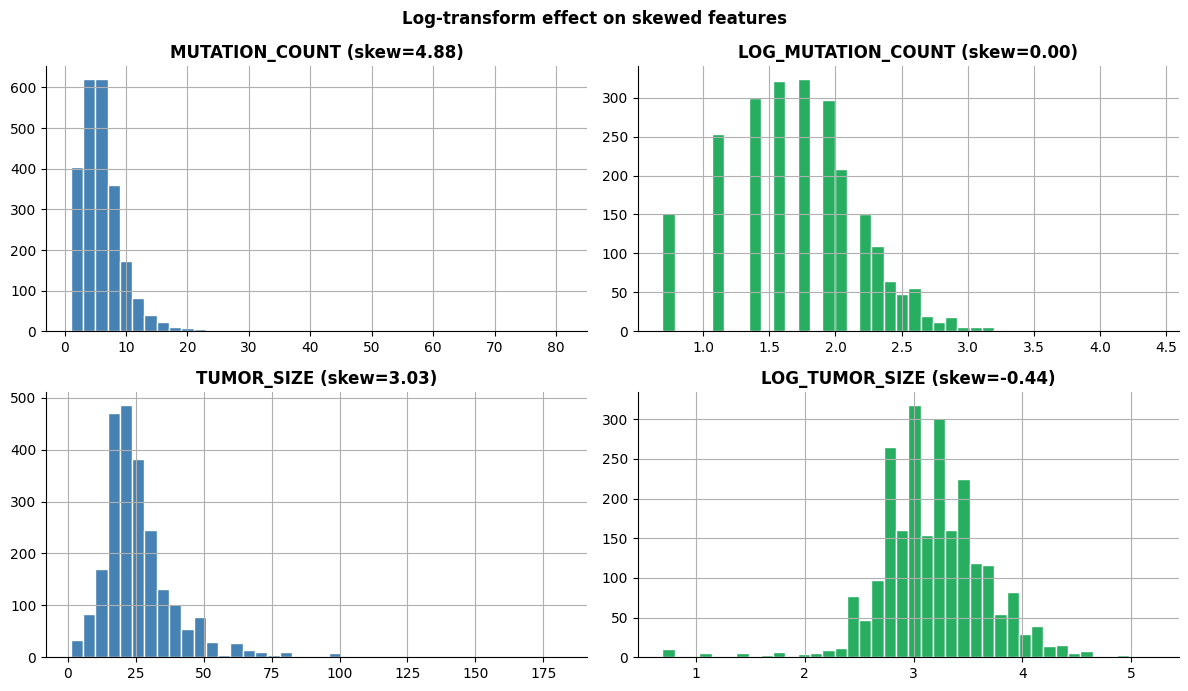

In [58]:
# Compare original vs log-transformed distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

pairs = [('MUTATION_COUNT', 'LOG_MUTATION_COUNT'), ('TUMOR_SIZE', 'LOG_TUMOR_SIZE')]
for row, (orig, log) in enumerate(pairs):
    if orig in df_eng.columns and log in df_eng.columns:
        df_eng[orig].dropna().hist(bins=40, ax=axes[row][0], color='steelblue', edgecolor='white')
        axes[row][0].set_title(f'{orig} (skew={df_eng[orig].skew():.2f})', fontweight='bold')
        df_eng[log].dropna().hist(bins=40, ax=axes[row][1], color='#27ae60', edgecolor='white')
        axes[row][1].set_title(f'{log} (skew={df_eng[log].skew():.2f})', fontweight='bold')

plt.suptitle('Log-transform effect on skewed features', fontweight='bold')
plt.tight_layout()
plt.savefig('results/eda/log_transform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary — Feature audit table

A complete log of every decision made, per the Checkpoint 2 deliverable requirement:
- **Dropped features** with justification (domain, leakage, low-info, redundancy)
- **Kept features** with role
- **Engineered features** with rationale

This gets saved to `results/feature_selection.csv`.

In [59]:
feature_audit = []

# Dropped — domain knowledge
for col in DROP_DOMAIN:
    feature_audit.append({'feature': col, 'decision': 'DROP', 'reason': domain_decisions.get(col, ('',''))[1],'stage': 'domain'})

# Dropped — leakage
for col in LEAKAGE_COLS:
    feature_audit.append({'feature': col, 'decision': 'DROP', 'reason': domain_decisions.get(col, ('',''))[1], 'stage': 'leakage'})

# Dropped — redundancy
for col in REDUNDANCY_DROP:
    feature_audit.append({'feature': col, 'decision': 'DROP', 'reason': 'Redundant with another kept feature (high correlation or derived variable)', 'stage': 'redundancy'})

# Kept features
OUTCOME_COLS = ['OS_MONTHS', 'OS_STATUS']
for col in df_eng.columns:
    if col in OUTCOME_COLS:
        feature_audit.append({'feature': col, 'decision': 'OUTCOME', 'reason': 'Target variable — not a predictor', 'stage': 'outcome'})
    elif col in engineered_features:
        feature_audit.append({'feature': col, 'decision': 'ENGINEERED', 'reason': 'New feature created from domain knowledge', 'stage': 'engineering'})
    else:
        feature_audit.append({'feature': col, 'decision': 'KEEP', 'reason': domain_decisions.get(col, ('', 'Selected for modeling'))[1], 'stage': 'keep'})

audit_df = pd.DataFrame(feature_audit)
print('Feature audit summary:')
print(audit_df['decision'].value_counts().to_string())
print()
print(audit_df.to_string(index=False))

os.makedirs('results', exist_ok=True)
audit_df.to_csv('results/feature_selection.csv', index=False)
print('\nSaved to results/feature_selection.csv')

Feature audit summary:
decision
KEEP          23
DROP          17
ENGINEERED     6
OUTCOME        2

             feature   decision                                                                      reason       stage
            Study ID       DROP                                          Identifier — no predictive content      domain
          Patient ID       DROP                                          Identifier — no predictive content      domain
           Sample ID       DROP                                          Identifier — no predictive content      domain
         CANCER_TYPE       DROP                                        Constant: all rows = "Breast Cancer"      domain
  CANCER_TYPE_DETAIL       DROP                                      Near-constant: mostly Ductal Carcinoma      domain
       ONCOTREE_CODE       DROP                       Near-constant: mostly IDC, redundant with cancer type      domain
           N_SAMPLES       DROP                Administrati

In [60]:
# Save the final processed dataframe
df_eng.to_csv('results/df_processed.csv', index=False)
print(f'Final processed dataset saved: {df_eng.shape[0]} patients, {df_eng.shape[1]} columns')
print(f'\nFinal feature list:')
for col in sorted(df_eng.columns):
    role = audit_df.set_index('feature').loc[col, 'decision'] if col in audit_df['feature'].values else 'KEEP'
    print(f'  {role:12s}  {col}')

Final processed dataset saved: 2509 patients, 31 columns

Final feature list:
  KEEP          AGE_AT_DIAGNOSIS
  ENGINEERED    AGE_GROUP
  KEEP          BREAST_SURGERY
  KEEP          CELLULARITY
  KEEP          CHEMOTHERAPY
  KEEP          CHEMOTHERAPY_BIN
  KEEP          CLAUDIN_SUBTYPE
  KEEP          ER_IHC
  KEEP          ER_STATUS
  KEEP          GRADE
  KEEP          HER2_SNP6
  KEEP          HER2_STATUS
  ENGINEERED    HIGH_MUTATION_BURDEN
  KEEP          HISTOLOGIC_SUBTYPE
  KEEP          HORMONE_THERAPY
  KEEP          HORMONE_THERAPY_BIN
  KEEP          INTCLUST
  ENGINEERED    LOG_MUTATION_COUNT
  ENGINEERED    LOG_TUMOR_SIZE
  KEEP          LYMPH_NODES_POS
  KEEP          MENOPAUSAL_STATE
  KEEP          MUTATION_COUNT
  ENGINEERED    NODE_POSITIVE
  OUTCOME       OS_MONTHS
  OUTCOME       OS_STATUS
  KEEP          PR_STATUS
  KEEP          RADIO_THERAPY
  KEEP          RADIO_THERAPY_BIN
  ENGINEERED    TREATMENT_INTENSITY
  KEEP          TUMOR_SIZE
  KEEP          TUMOR_S

## Key takeaways

| Step | What we found |
|---|---|
| Distributions | Several features are right-skewed (MUTATION_COUNT, TUMOR_SIZE) → log-transform applied |
| Missingness | ~529 patients missing OS/subtype data — dropped for survival analysis |
| Relationships | NPI is a near-linear composite of GRADE+SIZE+NODES → dropped as redundant |
| Outliers | A small number of patients have extreme mutation counts — flagged but retained |
| Domain filter | Dropped 9 identifier/constant/irrelevant columns |
| Leakage | Dropped VITAL_STATUS, RFS_MONTHS, RFS_STATUS for diagnosis-time prediction |
| Redundancy | Dropped NPI, TMB_NONSYNONYMOUS, ER_IHC, HER2_SNP6, THREEGENE |
| Engineering | Created 6 new features: log transforms, age groups, treatment intensity, mutation flag, node flag |

